## 01 - Exploratory Data Analysis and Incidence Calculation

This notebook performs exploratory data analysis (EDA) and computes leptospirosis incidence rates using the consolidated monthly district-level dataset(final Source data file).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import requests, io

In [2]:


sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 10

DATA_PATH = "../../data/processed/preprocessed_consolidated_dataframe.csv"

# Load data
preprocessed_consolidated_dataframe = pd.read_csv(DATA_PATH)
print(f"Records: {len(preprocessed_consolidated_dataframe):,}")
print(f"Columns: {list(preprocessed_consolidated_dataframe.columns)}")
print(preprocessed_consolidated_dataframe.head())


Records: 5,100
Columns: ['District', 'Month', 'Cases', 'Year', 'YearMonth', 'Precipitation_mm', 'Temp_Min_C', 'Temp_Max_C', 'Soil_Moisture_0_7cm', 'MRiceArea', 'MRiceYield', 'SRiceArea', 'SRiceYield', 'Population', 'Households', 'mean_temp', 'BIO1', 'BIO2', 'BIO3', 'BIO4', 'BIO5', 'BIO6', 'BIO7', 'BIO8', 'BIO9', 'BIO10', 'BIO11', 'BIO12', 'BIO13', 'BIO14', 'BIO15', 'BIO16', 'BIO17', 'BIO18', 'BIO19']
  District  Month  Cases  Year YearMonth  Precipitation_mm  Temp_Min_C  \
0   Ampara      1    1.0  2008   2008-01        177.600000     19.8505   
1   Ampara      2    3.0  2008   2008-02        121.000000     18.9005   
2   Ampara      3    0.0  2008   2008-03        293.600000     21.8005   
3   Ampara      4    1.0  2008   2008-04        119.000010     23.0505   
4   Ampara      5    4.0  2008   2008-05         34.600002     24.3005   

   Temp_Max_C  Soil_Moisture_0_7cm  MRiceArea  ...    BIO10      BIO11  \
0     29.6005             0.380341    64490.0  ...  29.3005  24.642167   
1  

In [3]:
## Check the data types
preprocessed_consolidated_dataframe.dtypes

District                object
Month                    int64
Cases                  float64
Year                     int64
YearMonth               object
Precipitation_mm       float64
Temp_Min_C             float64
Temp_Max_C             float64
Soil_Moisture_0_7cm    float64
MRiceArea              float64
MRiceYield             float64
SRiceArea              float64
SRiceYield             float64
Population             float64
Households             float64
mean_temp              float64
BIO1                   float64
BIO2                   float64
BIO3                   float64
BIO4                   float64
BIO5                   float64
BIO6                   float64
BIO7                   float64
BIO8                   float64
BIO9                   float64
BIO10                  float64
BIO11                  float64
BIO12                  float64
BIO13                  float64
BIO14                  float64
BIO15                  float64
BIO16                  float64
BIO17   

In [4]:

# Basic cleaning: ensure numeric columns are numeric
numeric_cols = [
    "Cases", "Precipitation_mm", "Temp_Min_C", "Temp_Max_C",
    "Soil_Moisture_0_7cm", "MRiceArea", "MRiceYield",
    "SRiceArea", "SRiceYield", "Population", "Households"
    , "BIO1", "BIO2", "BIO3", "BIO4",
    "BIO5", "BIO6", "BIO7",
    "BIO8", "BIO9", "BIO10", "BIO11",
    "BIO12", "BIO13", "BIO14", "BIO15",
    "BIO16", "BIO17", "BIO18", "BIO19"
]


#### Incidence Calculation

 - cases/100000   
 - cases per 100k population  

In [5]:
# Compute incidence rate per 100,000 population
# Here incidence is defined at the district-month level

preprocessed_consolidated_dataframe["Incidence_per_100k"] = preprocessed_consolidated_dataframe["Cases"] / preprocessed_consolidated_dataframe["Population"] * 1e5

print(preprocessed_consolidated_dataframe[["District", "Year", "Month", "Cases", "Population","Precipitation_mm", "Temp_Min_C", "Temp_Max_C",
    "Soil_Moisture_0_7cm", "MRiceArea", "MRiceYield","SRiceArea", "SRiceYield", "Population", "Households",
     "Incidence_per_100k"]].head())
print("Incidence summary:")
print(preprocessed_consolidated_dataframe["Incidence_per_100k"].describe())


  District  Year  Month  Cases  Population  Precipitation_mm  Temp_Min_C  \
0   Ampara  2008      1    1.0    620469.0        177.600000     19.8505   
1   Ampara  2008      2    3.0    620469.0        121.000000     18.9005   
2   Ampara  2008      3    0.0    620469.0        293.600000     21.8005   
3   Ampara  2008      4    1.0    620469.0        119.000010     23.0505   
4   Ampara  2008      5    4.0    620469.0         34.600002     24.3005   

   Temp_Max_C  Soil_Moisture_0_7cm  MRiceArea  MRiceYield  SRiceArea  \
0     29.6005             0.380341    64490.0      4864.0    60168.0   
1     28.9005             0.362213    64490.0      4864.0    60168.0   
2     30.7505             0.385442    64490.0      4864.0    60168.0   
3     32.5505             0.359476    64490.0      4864.0    60168.0   
4     34.5505             0.269909    64490.0      4864.0    60168.0   

   SRiceYield  Population  Households  Incidence_per_100k  
0      4927.0    620469.0    152158.0            0

##### Save Processed dataset (with incidence rate)

In [6]:
##saved as a new csv
preprocessed_consolidated_dataframe.to_csv('../../data/processed/finaldataset/preprocessed_consolidated_incidence.csv',
                index=False)

#### 1. District-wise incidence distribution

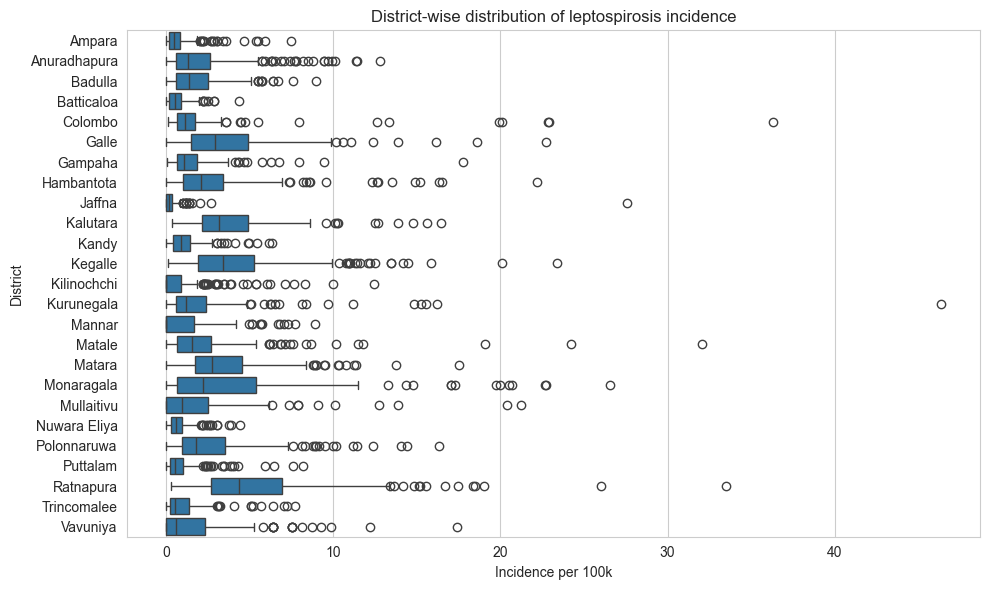

In [7]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=preprocessed_consolidated_dataframe,
    x="Incidence_per_100k",
    y="District"
)
plt.xlabel("Incidence per 100k")
plt.title("District-wise distribution of leptospirosis incidence")
plt.tight_layout()
plt.show()


#### 2. Temporal EDA: total cases and incidence over time(national)

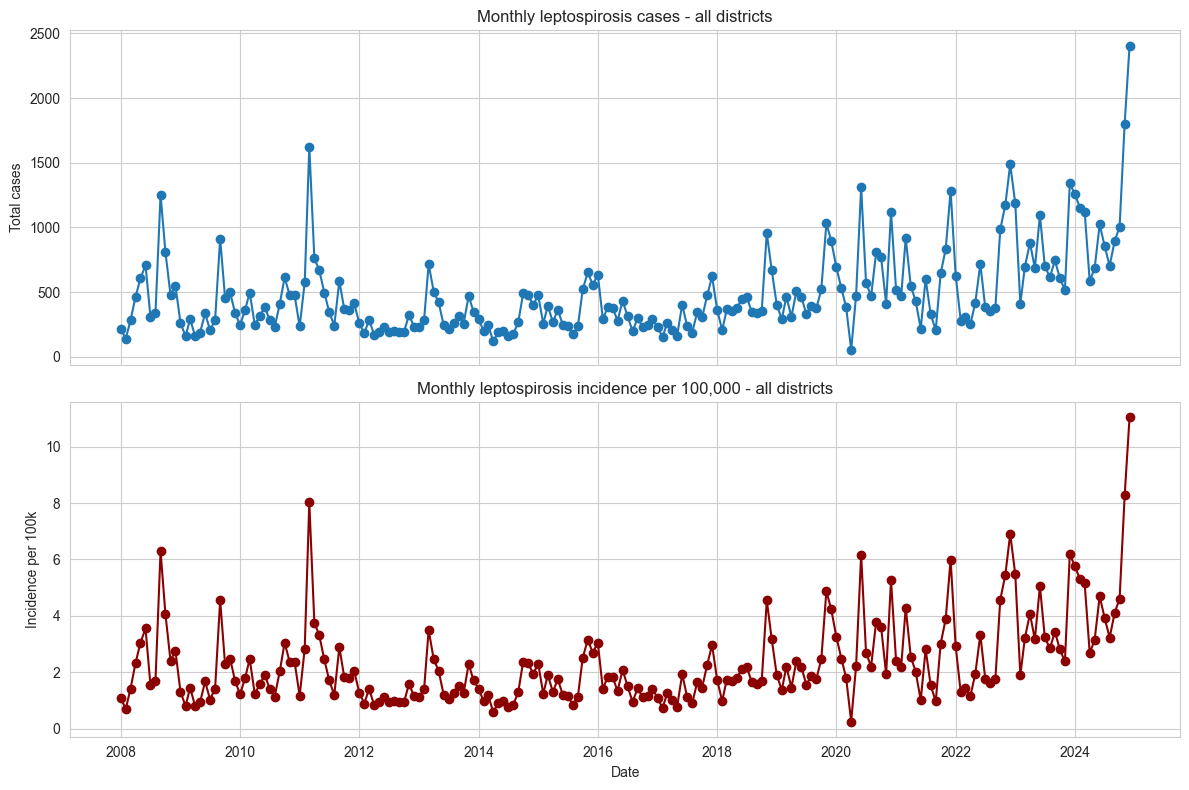

In [8]:
# Construct a proper monthly date
monthly = (
    # Year-Month-01
    preprocessed_consolidated_dataframe.assign(Date=lambda x: pd.to_datetime(x["Year"].astype(int).astype(str) + "-" + x["Month"].astype(int).astype(str) + "-01"))
    .groupby("Date", as_index=False)
    .agg({"Cases": "sum", "Population": "sum"})
)
monthly["Incidence_per_100k"] = monthly["Cases"] / monthly["Population"] * 1e5

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(monthly["Date"], monthly["Cases"], marker="o")
axes[0].set_ylabel("Total cases")
axes[0].set_title("Monthly leptospirosis cases - all districts")

axes[1].plot(monthly["Date"], monthly["Incidence_per_100k"], color="darkred", marker="o")
axes[1].set_ylabel("Incidence per 100k")
axes[1].set_xlabel("Date")
axes[1].set_title("Monthly leptospirosis incidence per 100,000 - all districts")

plt.tight_layout()
plt.show()


#### 3. Spatial / spatio-temporal pattern: mean monthly incidence by district and month

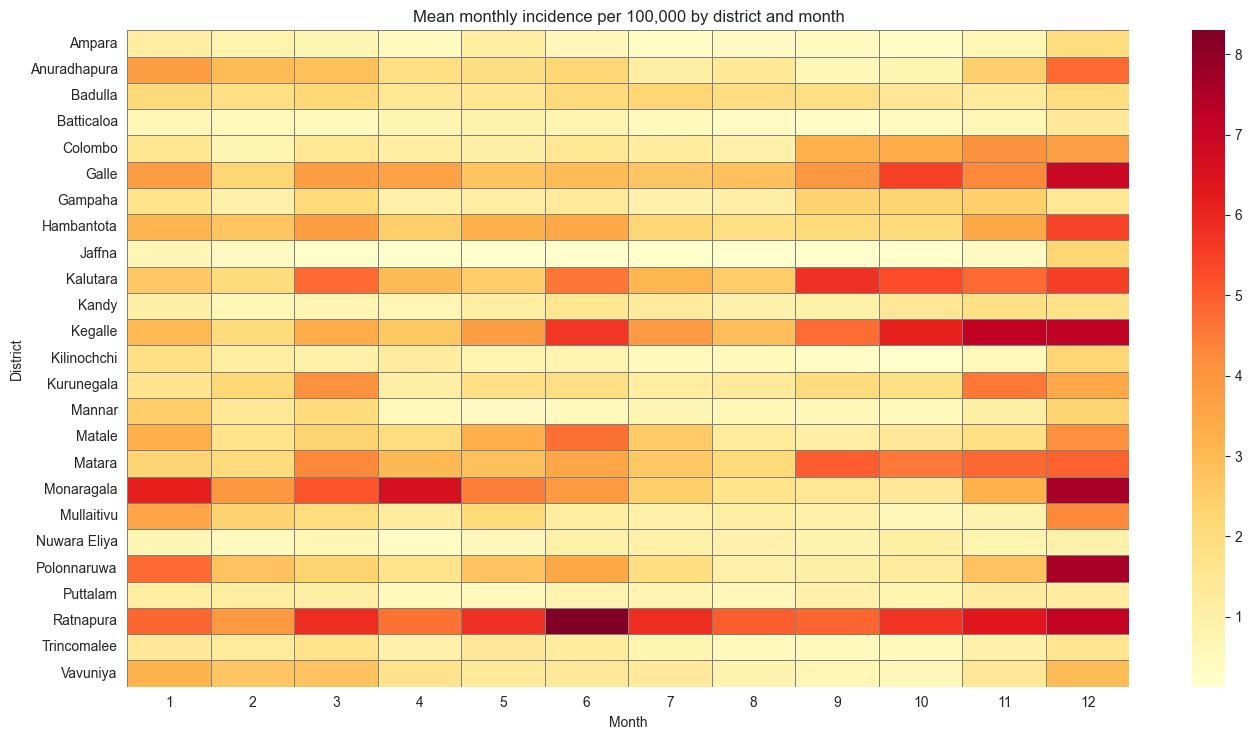

In [9]:
pivot_inc = (
    preprocessed_consolidated_dataframe.groupby(["District", "Month"], as_index=False)["Incidence_per_100k"].mean()
    .pivot(index="District", columns="Month", values="Incidence_per_100k")
)

plt.figure(figsize=(14, max(6, 0.3 * len(pivot_inc))))
sns.heatmap(pivot_inc, cmap="YlOrRd", linewidths=0.5, linecolor="grey")
plt.title("Mean monthly incidence per 100,000 by district and month")
plt.xlabel("Month")
plt.ylabel("District")
plt.tight_layout()
plt.show()


#### 4. Distribution of Median incidence rates

In [10]:

district_median = (
    preprocessed_consolidated_dataframe.groupby("District")["Incidence_per_100k"]
    .median()
    .reset_index()
    .rename(columns={"Incidence_per_100k": "Median_Incidence"})
)

print(district_median.sort_values("Median_Incidence", ascending=False))

        District  Median_Incidence
22     Ratnapura          4.365549
11       Kegalle          3.390229
9       Kalutara          3.149172
5          Galle          2.896286
16        Matara          2.761553
17    Monaragala          2.221581
7     Hambantota          2.100747
20   Polonnaruwa          1.791318
15        Matale          1.523719
2        Badulla          1.349044
1   Anuradhapura          1.278268
13    Kurunegala          1.173952
4        Colombo          1.111536
6        Gampaha          1.064873
18    Mullaitivu          0.929279
10         Kandy          0.891523
24      Vavuniya          0.581118
19  Nuwara Eliya          0.565646
23   Trincomalee          0.551177
21      Puttalam          0.513852
3     Batticaloa          0.511278
0         Ampara          0.443910
8         Jaffna          0.169045
14        Mannar          0.000000
12   Kilinochchi          0.000000


In [11]:
# 2.  Load Sri Lanka district GeoJSON (GADM level-2)
GADM_URL = "https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_LKA_1.json"

print("Downloading Sri Lanka district boundaries")
resp = requests.get(GADM_URL, timeout=60)
gdf = gpd.read_file(io.BytesIO(resp.content))

print(gdf["NAME_1"].tolist())  # check district names in GeoJSON

['Ampara', 'Anuradhapura', 'Badulla', 'Batticaloa', 'Colombo', 'Galle', 'Gampaha', 'Hambantota', 'Jaffna', 'Kalutara', 'Kandy', 'Kegalle', 'Kilinochchi', 'Kurunegala', 'Mannar', 'Matale', 'Matara', 'Moneragala', 'Mullaitivu', 'NuwaraEliya', 'Polonnaruwa', 'Puttalam', 'Ratnapura', 'Trincomalee', 'Vavuniya']


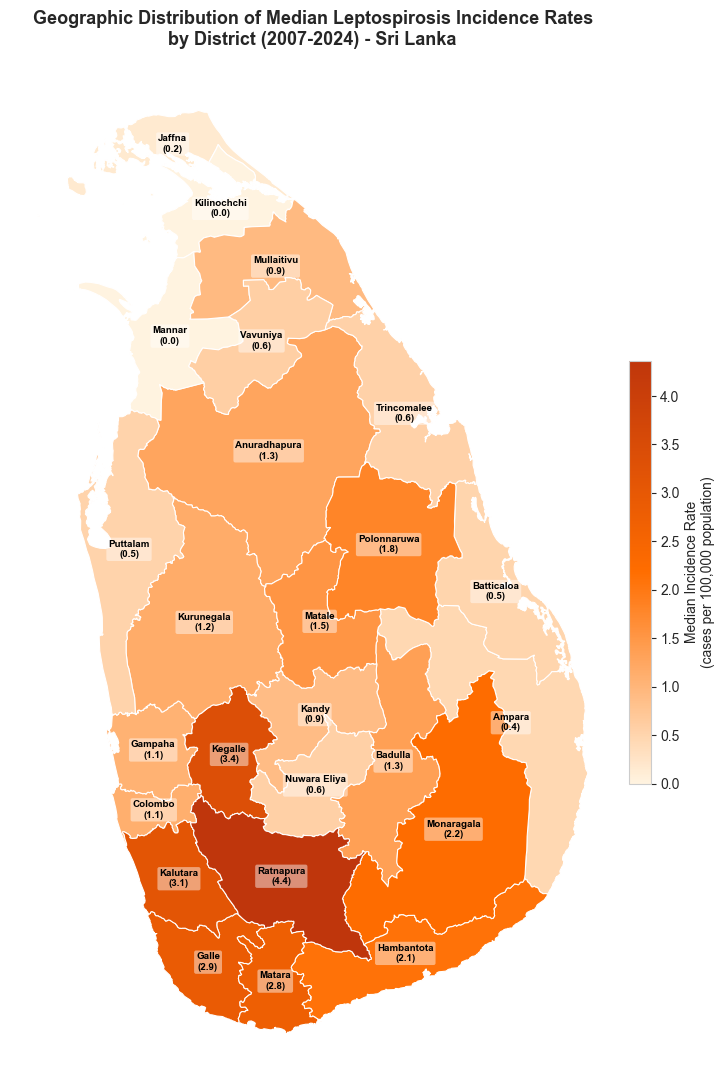

In [12]:
gadm_name_map = {
    "Ampara":        "Ampara",
    "Anuradhapura":  "Anuradhapura",
    "Badulla":       "Badulla",
    "Batticaloa":    "Batticaloa",
    "Colombo":       "Colombo",
    "Galle":         "Galle",
    "Gampaha":       "Gampaha",
    "Hambantota":    "Hambantota",
    "Jaffna":        "Jaffna",
    "Kalutara":      "Kalutara",
    "Kandy":         "Kandy",
    "Kegalle":       "Kegalle",
    "Kilinochchi":   "Kilinochchi",
    "Kurunegala":    "Kurunegala",
    "Mannar":        "Mannar",
    "Matale":        "Matale",
    "Matara":        "Matara",
    "Moneragala":    "Monaragala",
    "Mullaitivu":    "Mullaitivu",
    "NuwaraEliya":  "Nuwara Eliya",
    "Polonnaruwa":   "Polonnaruwa",
    "Puttalam":      "Puttalam",
    "Ratnapura":     "Ratnapura",
    "Trincomalee":   "Trincomalee",
    "Vavuniya":      "Vavuniya",
}


gdf["District"] = gdf["NAME_1"].map(gadm_name_map).fillna(gdf["NAME_1"])
gdf_withmedian = gdf.merge(district_median, on="District", how="left")


# Plot
fig, ax = plt.subplots(1, 1, figsize=(8, 11))

# Light -dark orange colormap
cmap = mcolors.LinearSegmentedColormap.from_list(
    "orange_map", ["#FFF3E0", "#FF6D00", "#BF360C"]
)

vmin = gdf_withmedian["Median_Incidence"].min()
vmax = gdf_withmedian["Median_Incidence"].max()
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

gdf_withmedian.plot(
    column="Median_Incidence",
    ax=ax,
    cmap=cmap,
    norm=norm,
    edgecolor="white",
    linewidth=0.8,
    missing_kwds={"color": "#EEEEEE", "label": "No data"},
)



# District labels with incidence value
for _, row in gdf_withmedian.iterrows():
    centroid = row.geometry.centroid
    val = row["Median_Incidence"]
    label = f"{row['District']}\n({val:.1f})" if pd.notna(val) else row["District"]
    ax.annotate(
        label,
        xy=(centroid.x, centroid.y),
        ha="center", va="center",
        fontsize=7, color="black",
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.45, ec="none"),
    )



# Colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Median Incidence Rate\n(cases per 100,000 population)", fontsize=10)

ax.set_title(
    "Geographic Distribution of Median Leptospirosis Incidence Rates\nby District (2007-2024) - Sri Lanka",
    fontsize=13, fontweight="bold", pad=14,
)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("../../reports/maps/sri_lanka_district_incidence_map.png", dpi=200, bbox_inches="tight")
plt.show()